The probability density function of two 1D Gaussians with variances $\sigma_1^2$, $\sigma_2^2$, means $\mu_1$, $\mu_2$, and mixture fraction $\pi$:
\begin{equation}
    P(x) = \pi \cdot \mathcal{N}(x|\mu_1, \sigma_1^2) + (1-\pi) \cdot \mathcal{N}(x|\mu_2, \sigma_2^2)
\end{equation}

As a second piece, we need the negative log-likelihood:
\begin{equation}
    \text{NLL} = -\sum{}{}{\log{P(x)}}
\end{equation}

Using pretty much any optimizer, we can then fit a GMM by minimizing the NLL:
\begin{equation}
    \argmin_{\sigma_1^2, \sigma_2^2, \pi}{(\text{NLL})}
\end{equation}

[2024-12-19 18:26:20 DEBUG    py.warnings 20632] /home/daniel/anaconda3/envs/pyfraglib/lib/python3.11/site-packages/scipy/optimize/_differentiable_functions.py:316: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)



3 [1.60093404e+02 3.20786348e+02 5.20753815e+02 1.34252598e+01
 2.02458687e+01 5.47017359e+01 6.00000027e-01 3.00282317e-01
 9.97176563e-02]


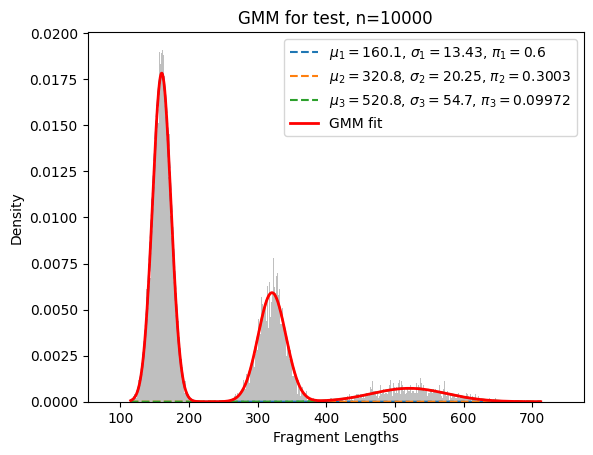

In [18]:
from pyfraglib.math import fit_gmm, plot_gmm
import numpy as np
import numpy.typing as npt
from scipy.optimize import LinearConstraint, minimize

n: int = 10000
mean1, mean2, mean3 = 160.0, 320.0, 520.0
std1, std2, std3 = 13.5, 20.0, 55.0
pi1, pi2, pi3 = 0.6, 0.3, 0.1

data1: npt.NDArray[np.float64] = np.random.normal(loc=mean1, scale=std1, size=int(n * pi1))
data2: npt.NDArray[np.float64] = np.random.normal(loc=mean2, scale=std2, size=int(n * pi2))
data3: npt.NDArray[np.float64] = np.random.normal(loc=mean3, scale=std3, size=int(n * pi3))
data: npt.NDArray[np.float64] = np.hstack([data1, data2, data3])  # type: ignore

_, n, params = fit_gmm(data, "../configs/gmm.json")
print(n, params)
plot_gmm(data, n, params, ".", "test")

In [ ]:
fragfile = pf.FragFile("/mnt/ramses/scratch/dschuet7/nf_out/ctrl1/ctrl1.frag")
frag_lens = []
for fragment in fragfile:
    if not fragment.is_bogus:
        frag_lens.append(fragment.length)

In [ ]:
initial_params: list[int] = [160, 320, 480, 52.5, 52.5, 52.5, 0.7, 0.2, 0.1]
bounds = [(50, 250), (250, 450), (450, 650), (1, 100), (1, 100), (1, 100), (1e-6, 1-1e-6), (1e-6, 1-1e-6), (1e-6, 1-1e-6)]
lin_constraint: LinearConstraint = LinearConstraint(
    A=[[0, 0, 0, 0, 0, 0, 1, 1, 1]],  lb=1, ub=1  # type: ignore
)
n=3

result = minimize(  # type: ignore
    # pm.negative_log_likelihood,
    lambda x: pm.negative_log_likelihood(x, 3, frag_lens) / 1000,
    initial_params,
    bounds=bounds,
    constraints=(lin_constraint, ),
    method="SLSQP",
    # method="trust-constr",
    # @NOTE(ds): The optimizer warns us that the objective seems linear.
    # But it really isn't, so we do not set the Hessian to zero.
    # > hess=hessian,
    options={
        "maxiter": 100,
        "disp": True,

    }
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 62414.86735372293
            Iterations: 27
            Function evaluations: 298
            Gradient evaluations: 27
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 62414.86735372293
       x: [ 1.666e+02  3.288e+02  4.972e+02  2.504e+01  3.921e+01
            1.000e+02  8.026e-01  1.540e-01  4.340e-02]
     nit: 27
     jac: [-1.465e-03  1.465e-03 -2.441e-03 -9.766e-04  1.465e-03
           -6.226e-01 -1.172e+04 -1.172e+04 -1.172e+04]
    nfev: 298
    njev: 27


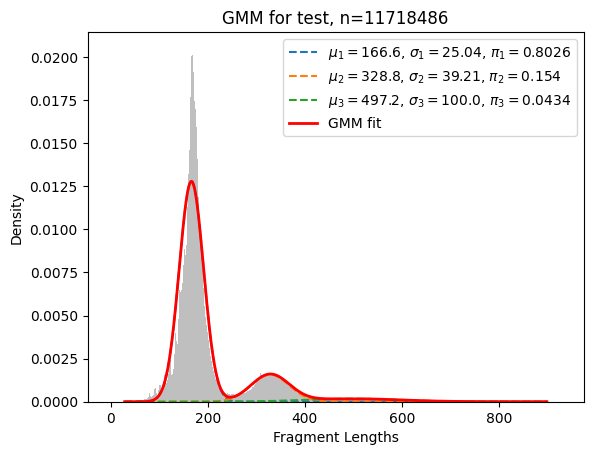

In [ ]:
plot_gmm(frag_lens, 3, result.x, "", "test")